This creates a sparse recovery problem. The true vector $x$ has only a few nonzero values and we observe compressed measurements $b = Ax$. The goal is to recover a sparse $x$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import linprog

np.random.seed(0)

# Problem dimensions
m = 60     # number of measurements
n = 200    # number of variables
s = 10     # sparsity level

# Create sparse true signal
x_true = np.zeros(n)
support = np.random.choice(n, s, replace=False)
x_true[support] = np.random.randn(s)

# Create measurement matrix and measurements
A = np.random.randn(m, n) / np.sqrt(m)
b = A @ x_true

lam = 1.0
MAX_ITER = 1000
alpha = 1.0

The problem is
$$
\min_{x} \ \lambda \|x\|_1 \quad \text{subject to} \quad Ax = b
$$

this is equivalent to
$$
\min_{x} \ \lambda \|x\|_1 + \iota_{\{Ax=b\}}(x)
$$

This is nonsmooth + nonsmooth, so it is much better for DRS than regular LASSO which is smooth + nonsmooth.

In [2]:
def objective(x):
    return lam * np.linalg.norm(x, 1)

def feasibility(x):
    return np.linalg.norm(A @ x - b)

DRS works well here because both proximal steps are easy
$$
\mathrm{prox}_{\lambda \|x\|_1}
$$

is soft-thresholding, and

$$
\mathrm{prox}_{\iota_{\{Ax=b\}}}
$$

is projection onto the constraint $Ax = b$.

In [3]:
def soft_threshold(v, tau):
    return np.sign(v) * np.maximum(np.abs(v) - tau, 0.0)


# Precompute for projection onto Ax = b
# Projection formula:
# proj(v) = v - A.T @ (A A.T)^(-1) @ (A v - b)

AAT = A @ A.T
c_factor = cho_factor(AAT + 1e-10 * np.eye(m), lower=True)

def prox_l1(v, alpha):
    return soft_threshold(v, alpha * lam)

def proj_affine(v):
    correction = A.T @ cho_solve(c_factor, A @ v - b)
    return v - correction

In [4]:
def drs(z0, max_iter=1000, alpha=1.0):
    z = z0.copy()

    obj_hist = []
    feas_hist = []

    for k in range(max_iter + 1):
        x = prox_l1(z, alpha)
        y = proj_affine(2 * x - z)

        z = z + y - x

        # y is feasible because it is projected onto Ax=b
        obj_hist.append(objective(y))
        feas_hist.append(feasibility(y))

    return y, np.array(obj_hist), np.array(feas_hist)

In [5]:
def adrs(z0, max_iter=1000, alpha=1.0, beta_cap=0.95):
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0

    obj_hist = []
    feas_hist = []

    best_obj = np.inf

    for k in range(max_iter + 1):
        # Acceleration step
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = min((t - 1) / t_new, beta_cap)

        w = z + beta * (z - z_prev)

        x = prox_l1(w, alpha)
        y = proj_affine(2 * x - w)

        z_new = w + y - x

        obj_val = objective(y)
        feas_val = feasibility(y)

        # Restart if objective gets worse
        if obj_val > best_obj:
            w = z
            x = prox_l1(w, alpha)
            y = proj_affine(2 * x - w)
            z_new = w + y - x
            t_new = 1.0
            obj_val = objective(y)
            feas_val = feasibility(y)

        best_obj = min(best_obj, obj_val)

        obj_hist.append(obj_val)
        feas_hist.append(feas_val)

        z_prev = z
        z = z_new
        t = t_new

    return y, np.array(obj_hist), np.array(feas_hist)

This computes the true optimal objective value, so we can plot the objective gap
$$
F(x^k) - F^*
$$

In [6]:
# Solve min ||x||_1 subject to Ax=b
# Convert to LP:
# min sum(t)
# subject to -t <= x <= t, Ax=b

c = np.r_[np.zeros(n), np.ones(n)]

A_eq = np.hstack([A, np.zeros((m, n))])
b_eq = b

I = np.eye(n)

A_ub = np.vstack([
    np.hstack([ I, -I]),
    np.hstack([-I, -I])
])

b_ub = np.zeros(2 * n)

bounds = [(None, None)] * n + [(0, None)] * n

lp_result = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

F_star = lp_result.fun * lam

print("LP success:", lp_result.success)
print("Exact optimal value F* =", F_star)

LP success: True
Exact optimal value F* = 7.003879501498779


Runs both methods and compares how close they get to the true solution.

In [7]:
z0 = np.zeros(n)

x_drs, obj_drs, feas_drs = drs(z0, max_iter=MAX_ITER, alpha=alpha)
x_adrs, obj_adrs, feas_adrs = adrs(z0, max_iter=MAX_ITER, alpha=alpha)

gap_drs = np.maximum(obj_drs - F_star, 1e-16)
gap_adrs = np.maximum(obj_adrs - F_star, 1e-16)

print(f"DRS final objective gap  = {gap_drs[-1]:.2e}")
print(f"ADRS final objective gap = {gap_adrs[-1]:.2e}")

print(f"DRS final feasibility    = {feas_drs[-1]:.2e}")
print(f"ADRS final feasibility   = {feas_adrs[-1]:.2e}")

DRS final objective gap  = 1.01e-10
ADRS final objective gap = 1.01e-10
DRS final feasibility    = 3.77e-10
ADRS final feasibility   = 3.77e-10


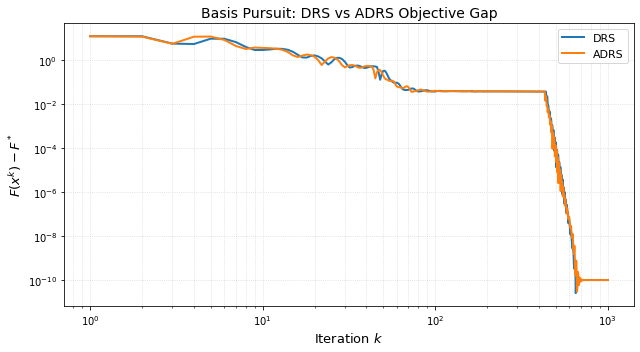

In [8]:
k = np.arange(MAX_ITER + 1)

plt.figure(figsize=(9, 5))

plt.loglog(k + 1, gap_drs, label="DRS", linewidth=2)
plt.loglog(k + 1, gap_adrs, label="ADRS", linewidth=2)

plt.xlabel("Iteration $k$", fontsize=13)
plt.ylabel(r"$F(x^k) - F^*$", fontsize=13)
plt.title("Basis Pursuit: DRS vs ADRS Objective Gap", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

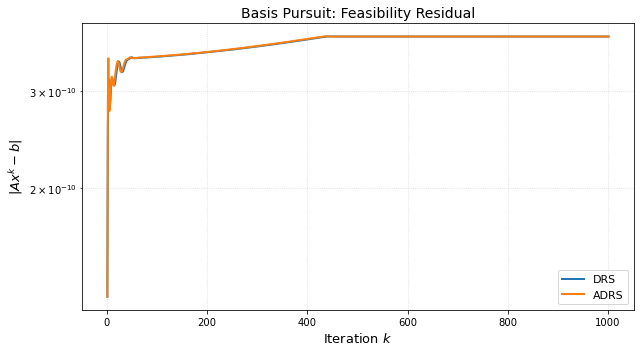

In [9]:
plt.figure(figsize=(9, 5))

plt.semilogy(k + 1, feas_drs, label="DRS", linewidth=2)
plt.semilogy(k + 1, feas_adrs, label="ADRS", linewidth=2)

plt.xlabel("Iteration $k$", fontsize=13)
plt.ylabel(r"$\|Ax^k-b\|$", fontsize=13)
plt.title("Basis Pursuit: Feasibility Residual", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()